In [1]:
import pickle 
import matplotlib.pyplot as plt

In [2]:
ucc_2_4_rustiq = 21
ucc_4_8_rustiq = 328
ucc_6_12_rustiq = 1909
ucc_8_16_rustiq = 7383
H2_rustiq = 15
LiH_rustiq = 647
BeH2_rustiq = 800
NH3_rustiq = 3876
H2O_rustiq = 1339
CO_rustiq = 6620

In [3]:
ucc_2_4 = 59
ucc_4_8 = 1187
ucc_6_12 = 7694
ucc_8_16 = 28090
LiH = 1675
BeH2 = 2411
NH3 = 11190
H2O = 4105
CO = 20858
H2 = 34

In [5]:
with open("H2.pkl", "rb") as f:
    data = pickle.load(f)

data

{0: [[12, 12, 12, 12, 12, 12, 12, 12, 12, 12],
  [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0],
  [0.503018856048584,
   1.0029487609863281,
   1.5025577545166016,
   2.003328323364258,
   2.5027458667755127,
   3.002772331237793,
   3.502964496612549,
   4.00296950340271,
   4.502620697021484,
   5.002434968948364],
  'OPENQASM 3.0;\ninclude "stdgates.inc";\ninput float[64] _φ_0_;\ninput float[64] _φ_1_;\ninput float[64] _φ_2_;\ninput float[64] _φ_3_;\ninput float[64] _φ_4_;\ninput float[64] _φ_5_;\ninput float[64] _φ_6_;\ninput float[64] _φ_7_;\ninput float[64] _φ_8_;\ninput float[64] _φ_9_;\ninput float[64] _φ_10_;\ninput float[64] _φ_11_;\ninput float[64] _φ_12_;\ninput float[64] _φ_13_;\nrz(2*_φ_5_) $0;\ns $0;\nrz(2*_φ_3_) $1;\nrz(2*_φ_1_) $2;\nrz(2*_φ_0_) $3;\ncx $2, $3;\ncx $1, $2;\ns $1;\ncx $0, $1;\nh $0;\nrz(2*_φ_9_) $0;\nh $0;\nrz(2*_φ_13_) $1;\nrz(2*_φ_11_) $2;\nh $2;\nrz(2*_φ_2_) $3;\nh $3;\ncx $2, $3;\ncx $0, $3;\nh $0;\nrz((-2)*_φ_7_) $0;\nh $0;\nrz(pi) $0;\nh $2;\n

In [66]:
def make_graph(file_name, value):
    with open(file_name, "rb") as f:
        data_dict = pickle.load(f)
    title = file_name.replace("_hrdwr.pkl", "").replace(".pkl", "")
    for key in data_dict.keys():
        plt.axhline(y=1, color='r', linestyle='--', label= "Rustiq")
        lst = [x/value for x in data_dict[key][0]]
        plt.xlabel("Input Total Time")
        plt.ylabel("Average CNOT count relative to Rustiq")
        plt.plot(data_dict[key][1], lst, label= "MonteQ")
        plt.legend()
        plt.title(f"{title} Parameter {key}")
        plt.legend(loc='center right', frameon=False, fontsize="small")
        plt.savefig(f"{title} Parameter {key}")
        plt.show()

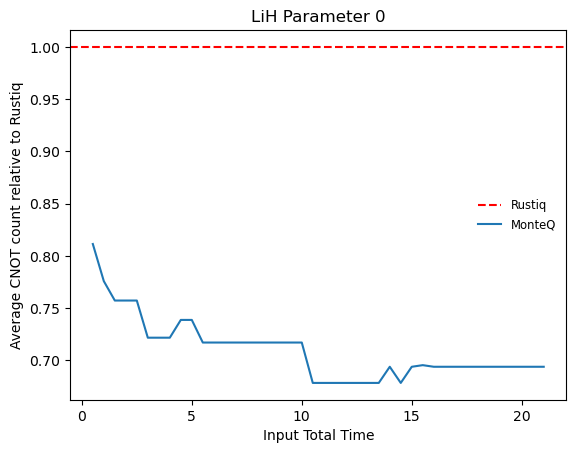

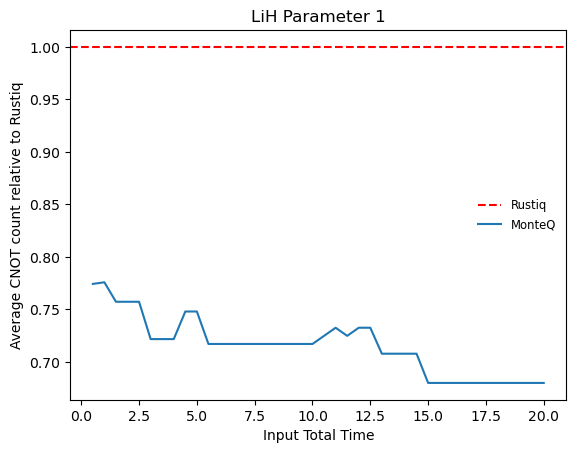

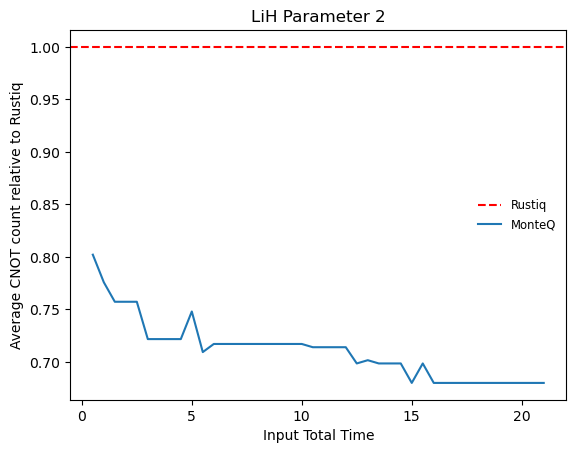

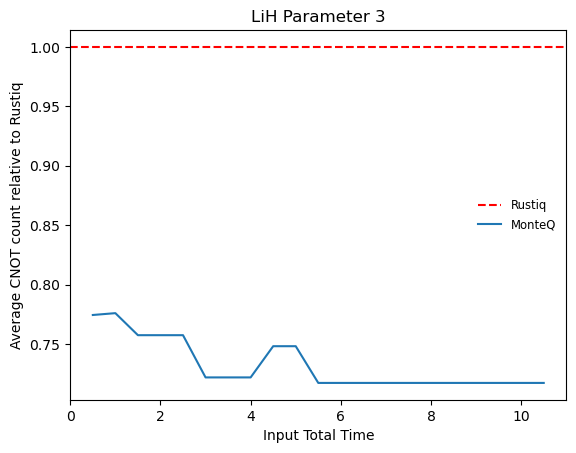

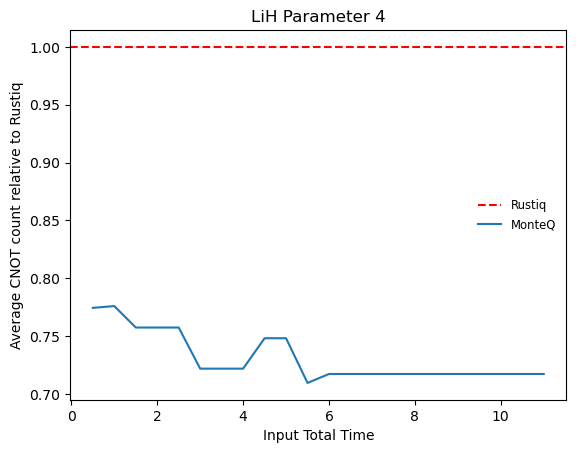

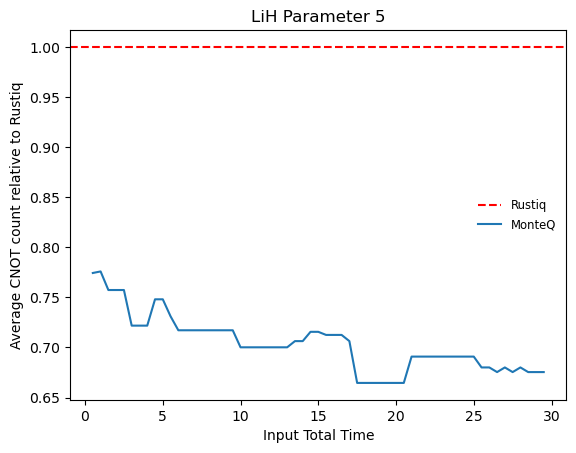

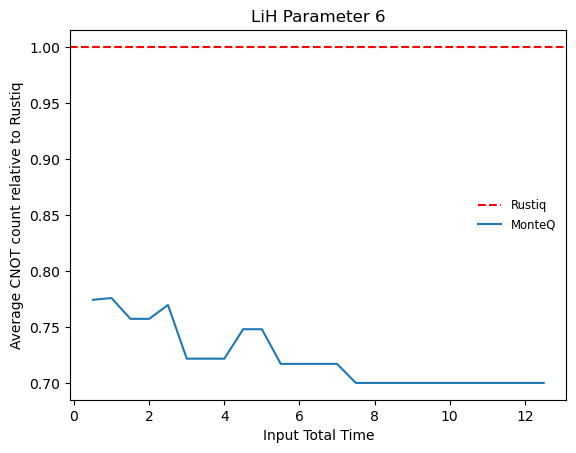

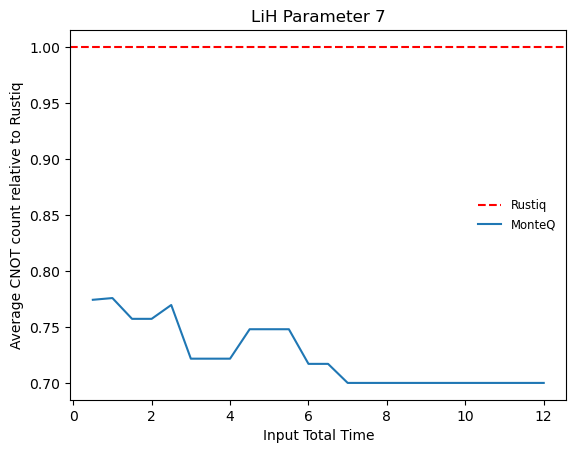

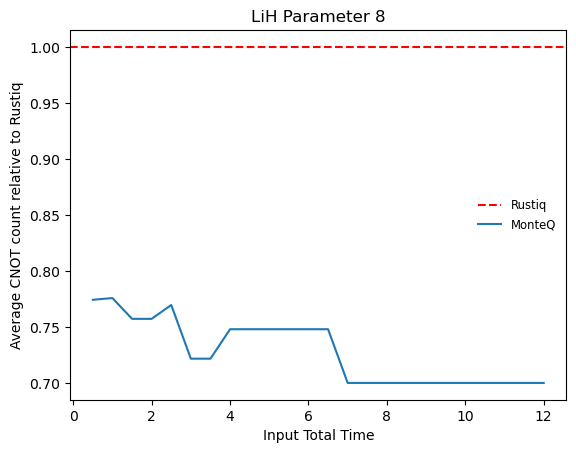

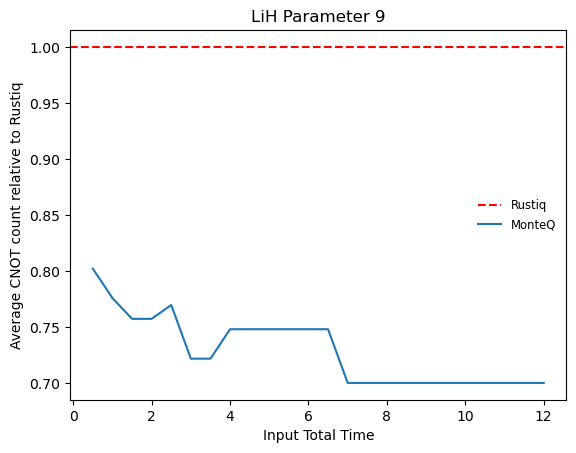

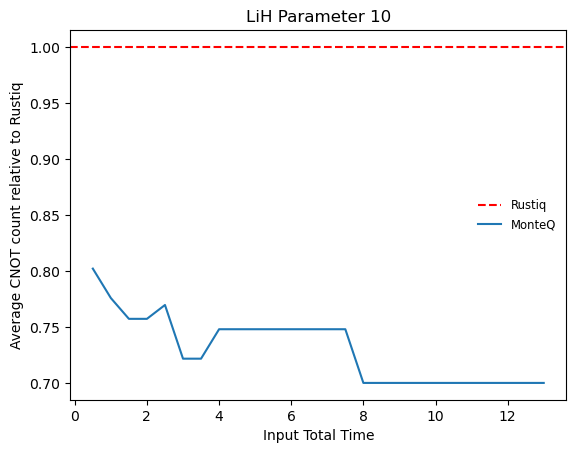

In [67]:
make_graph("LiH.pkl", LiH_rustiq)

In [38]:
import json

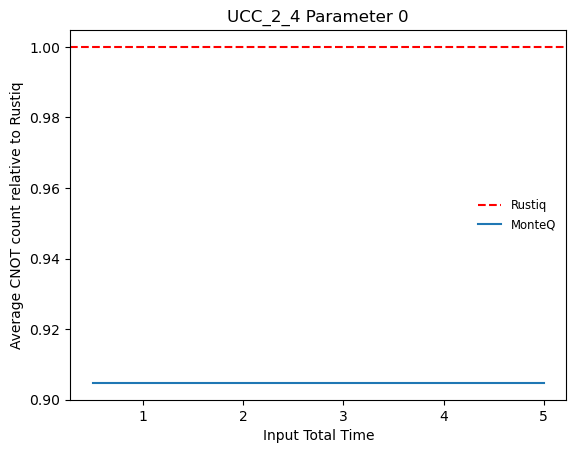

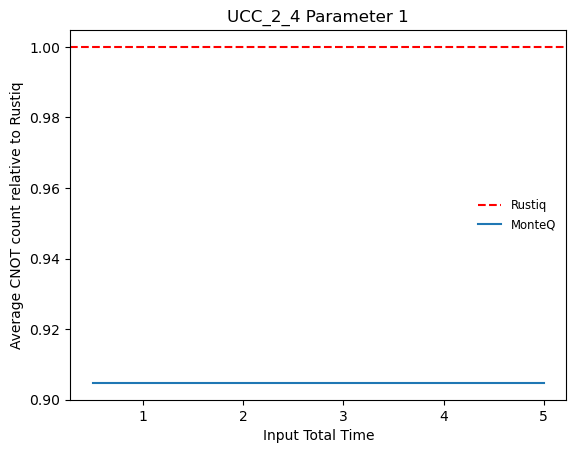

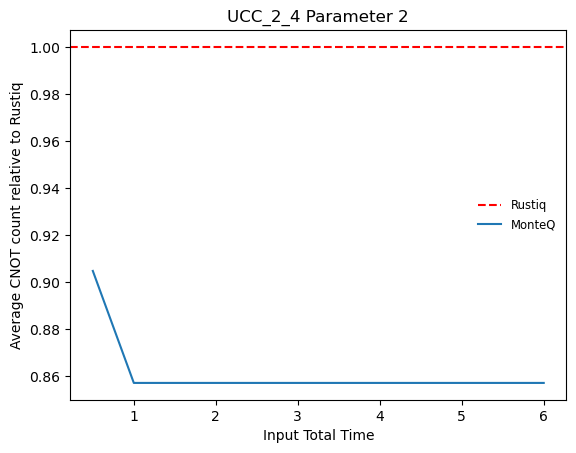

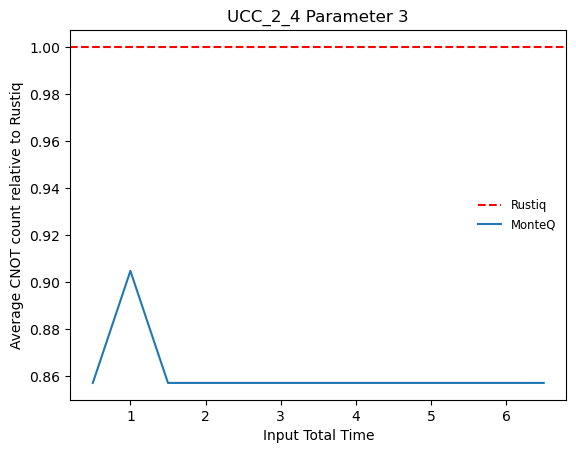

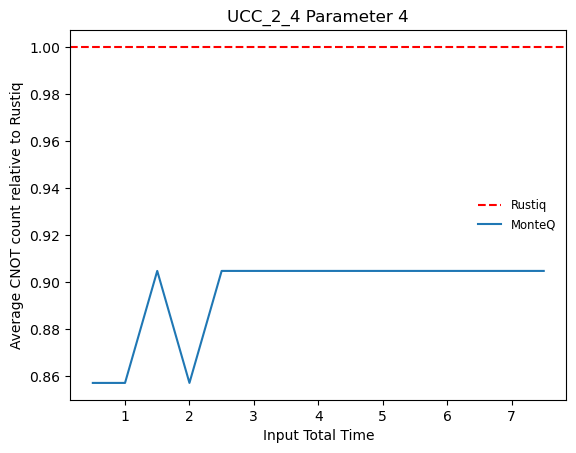

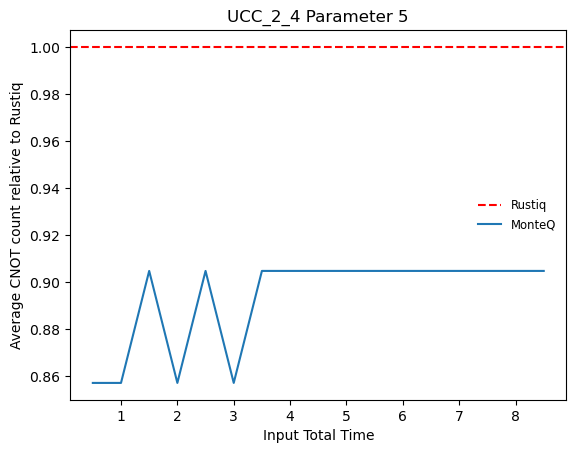

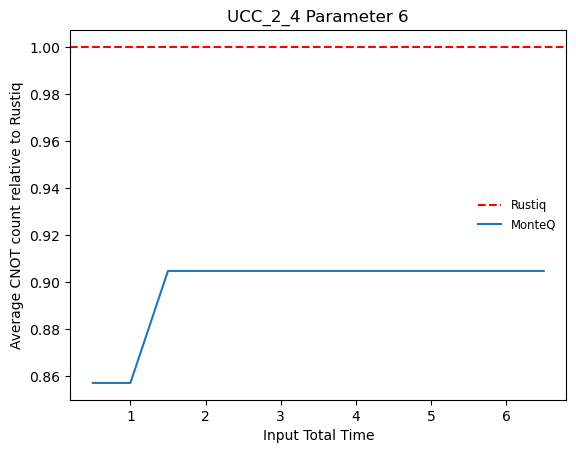

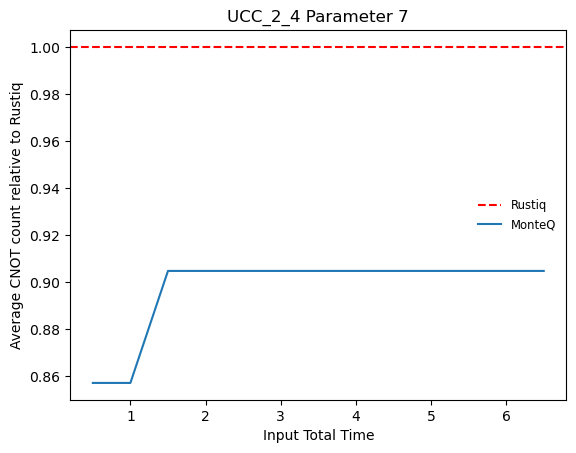

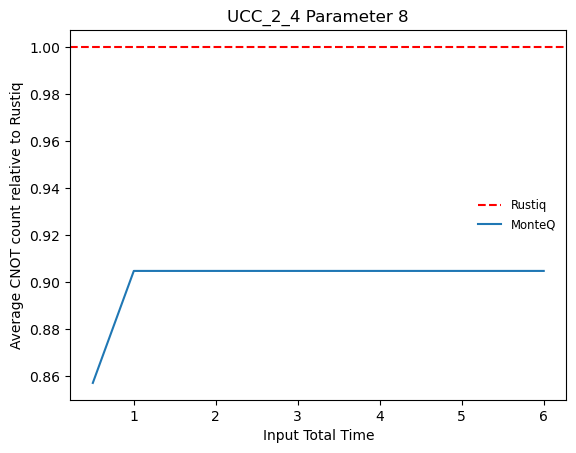

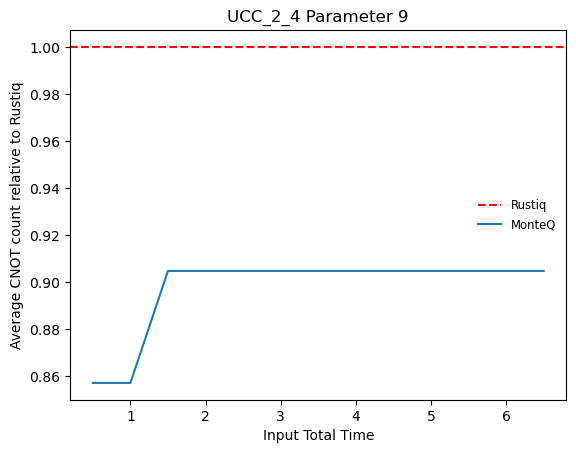

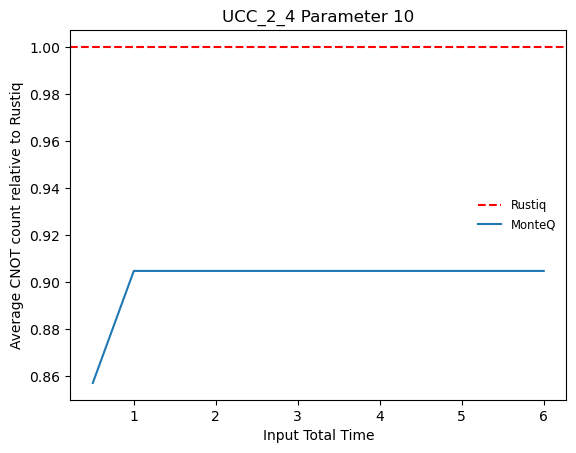

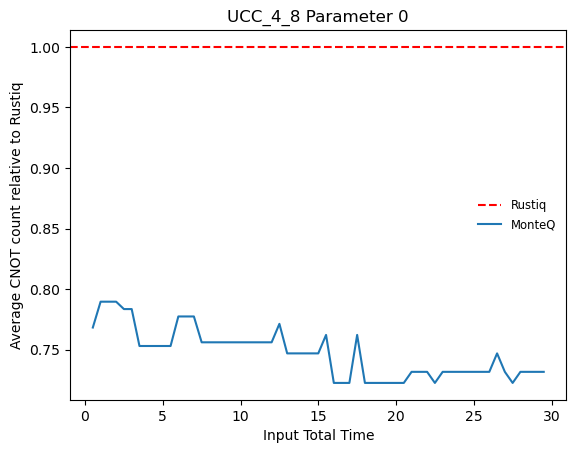

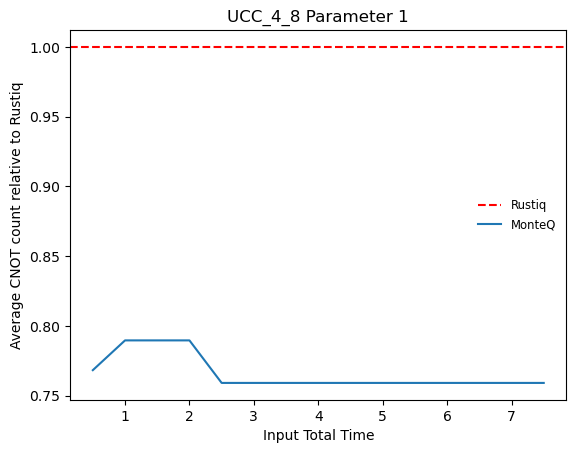

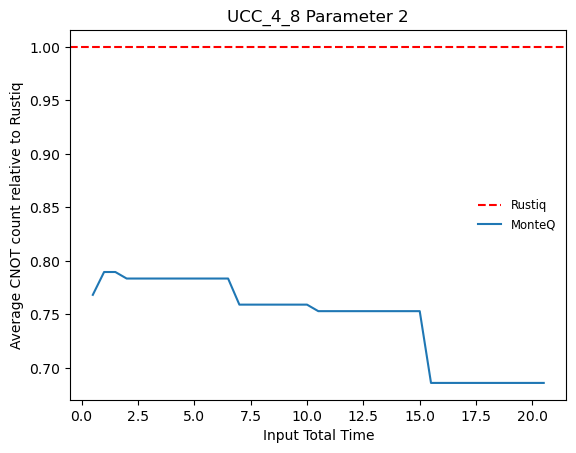

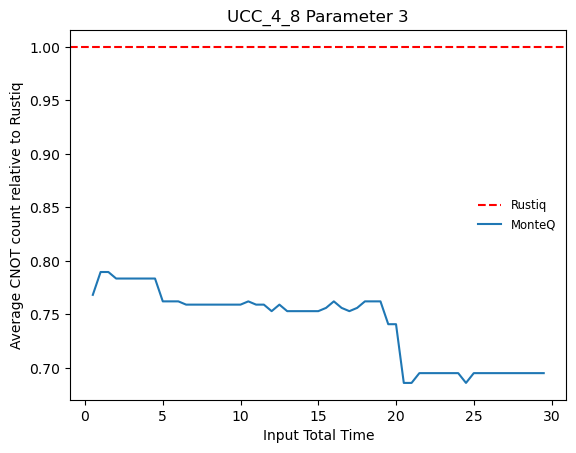

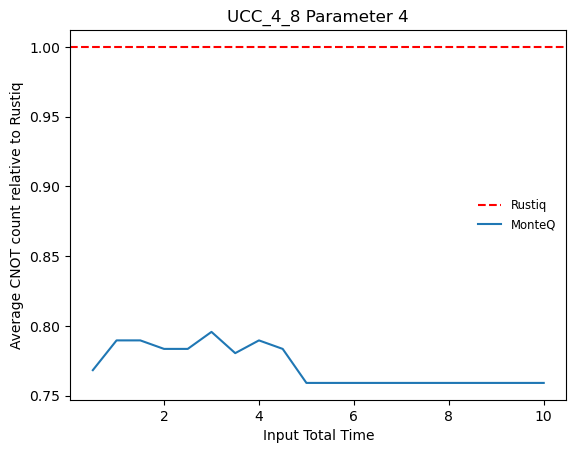

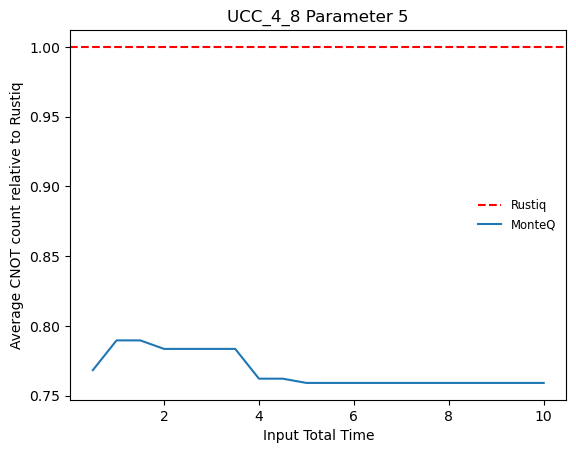

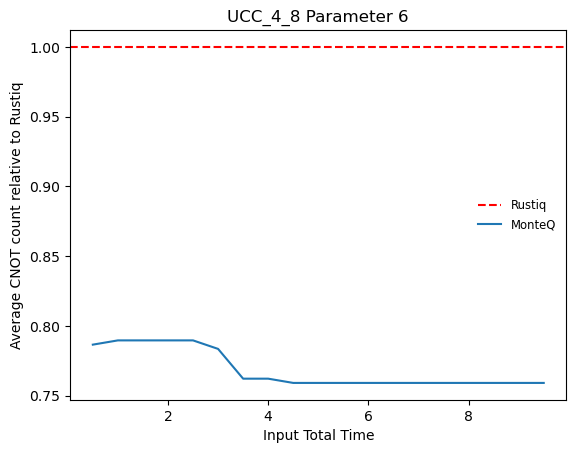

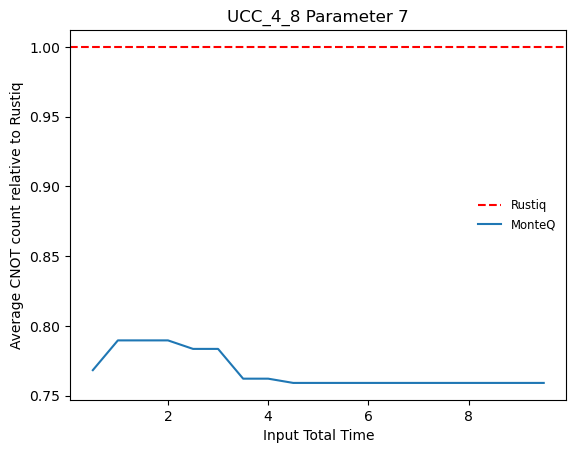

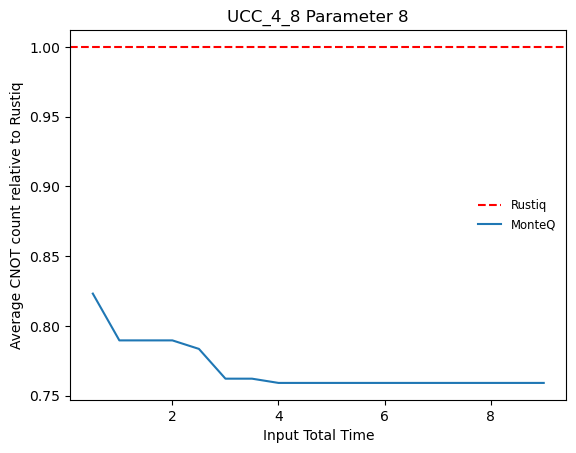

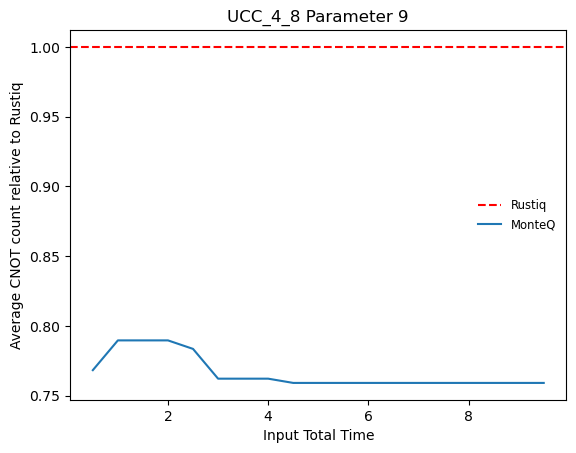

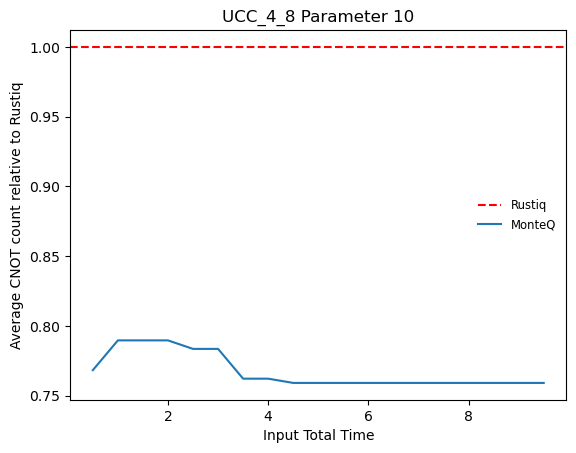

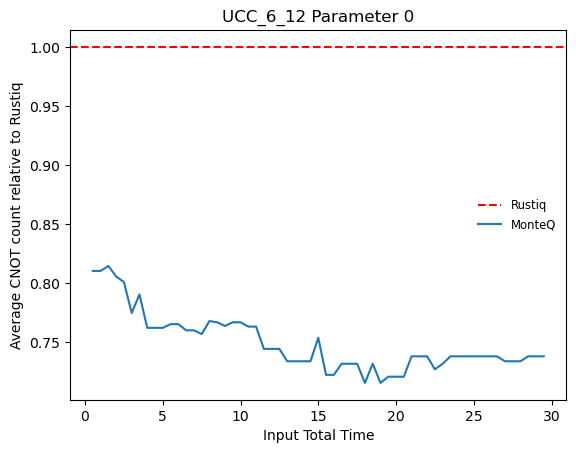

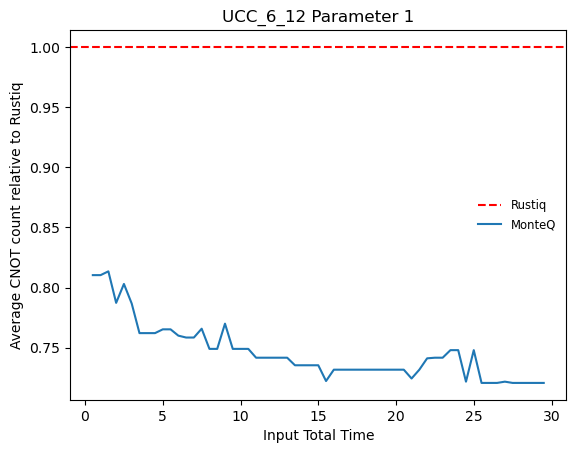

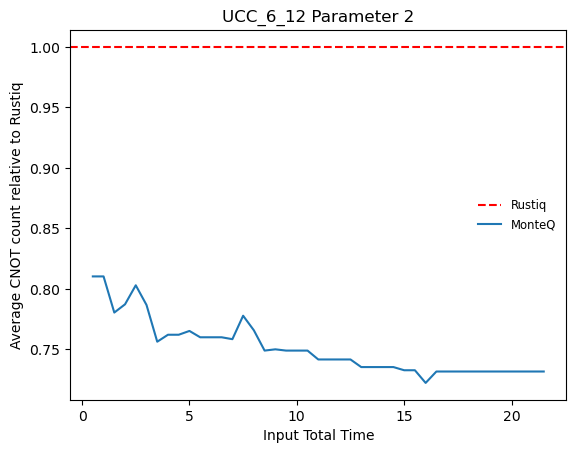

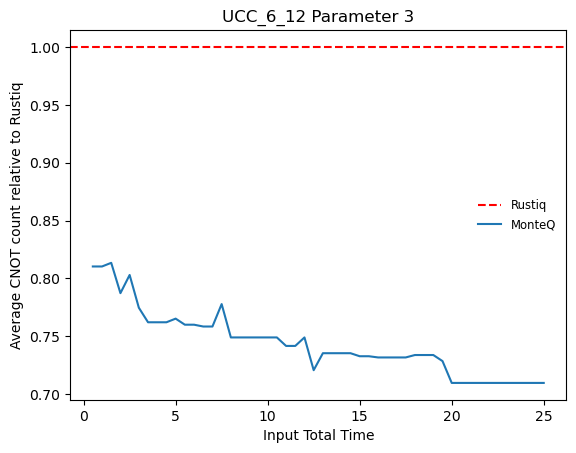

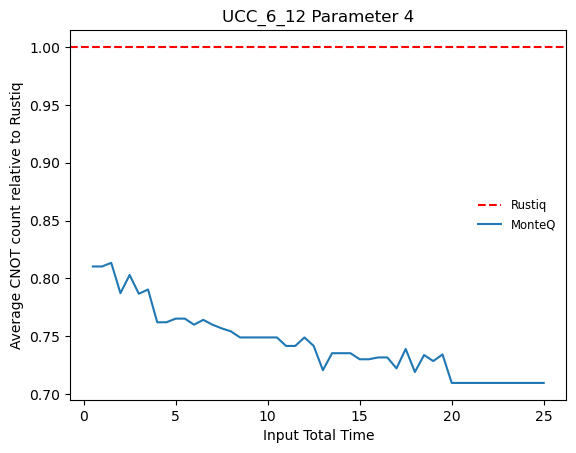

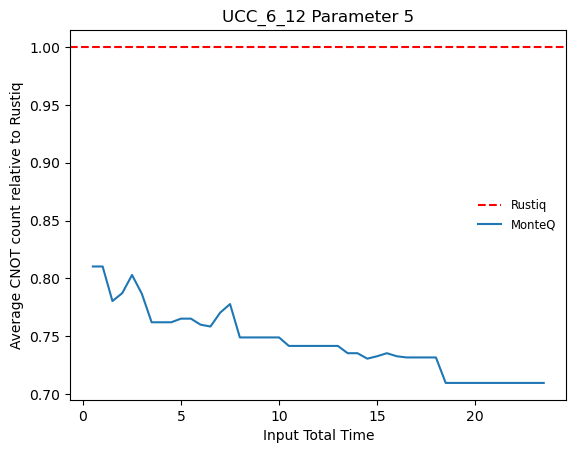

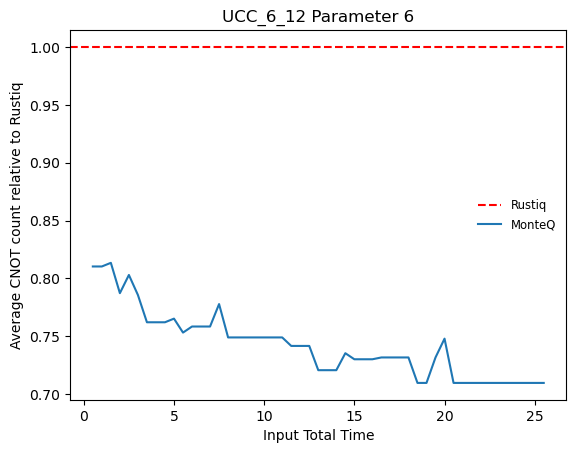

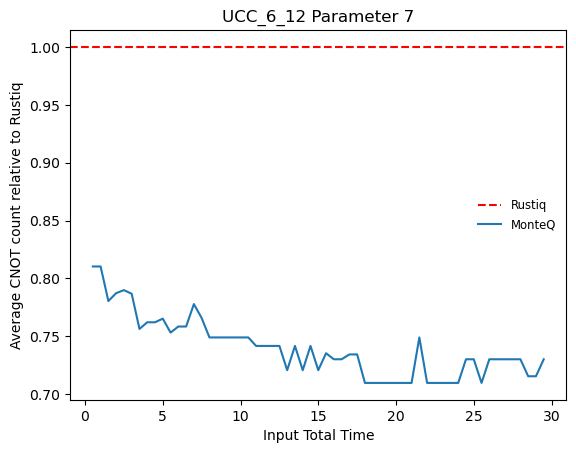

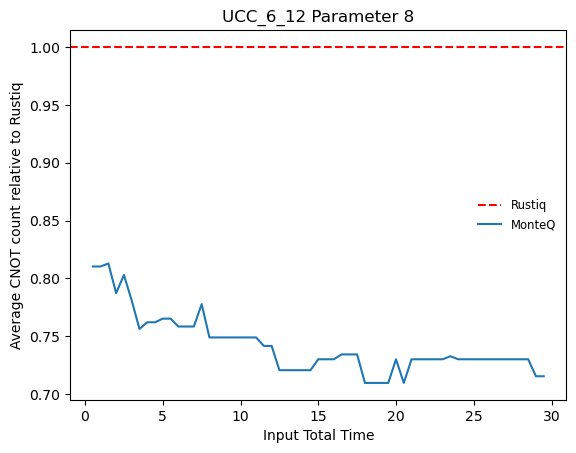

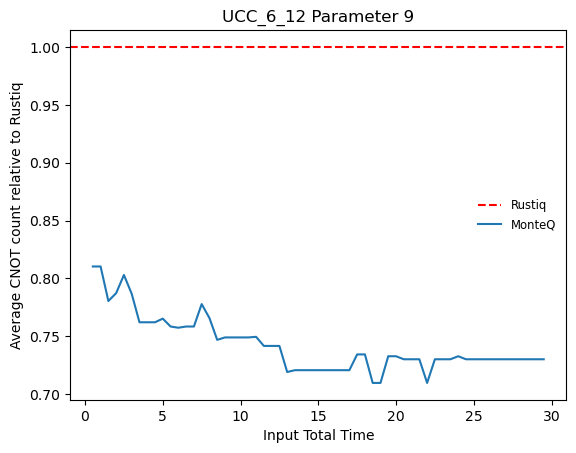

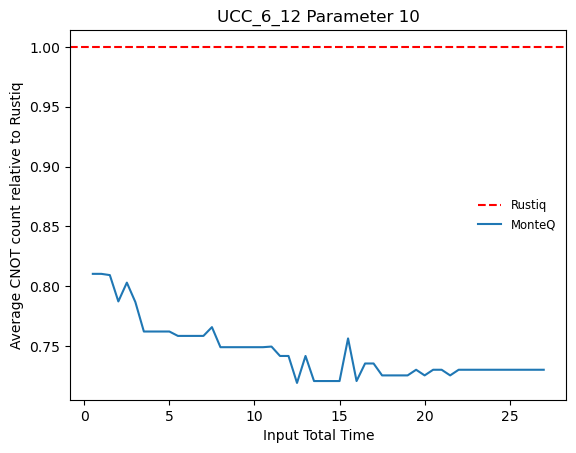

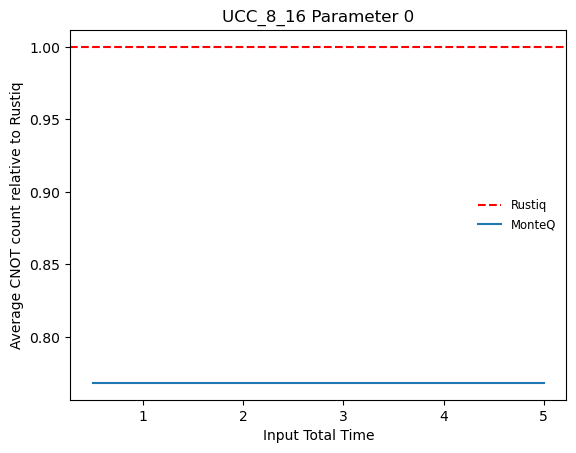

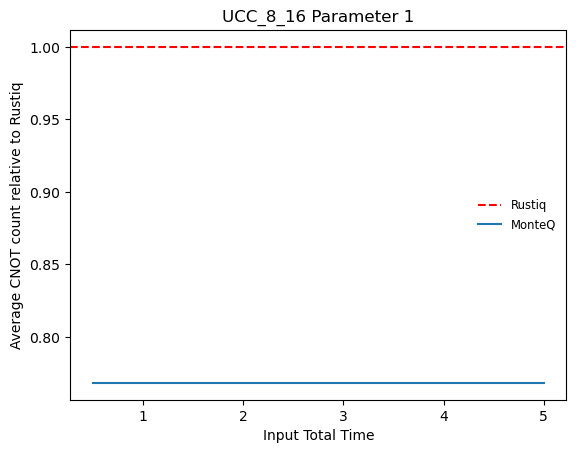

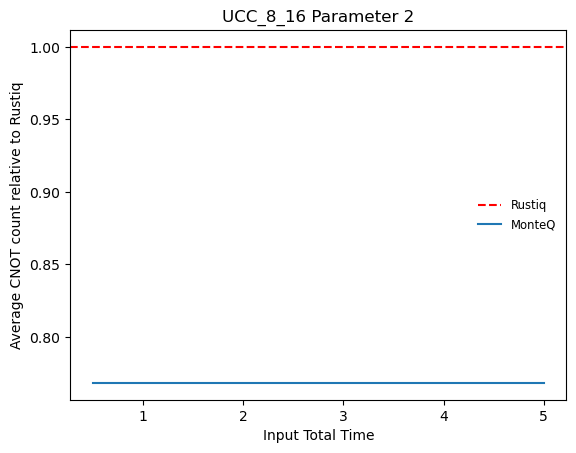

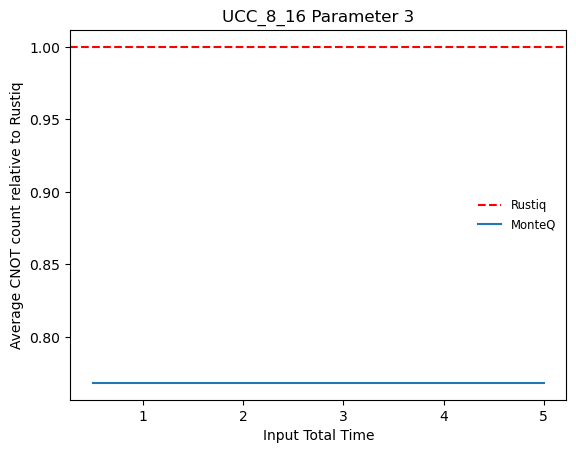

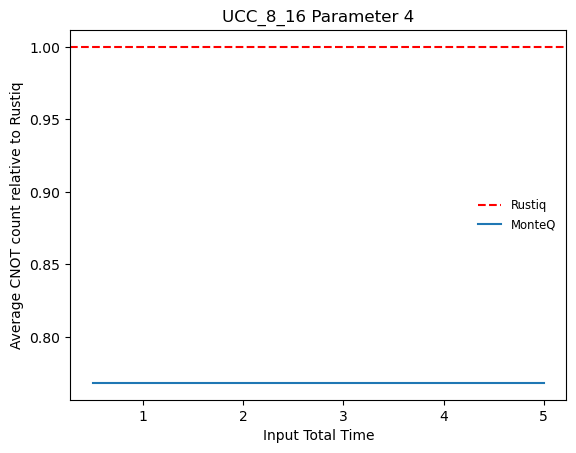

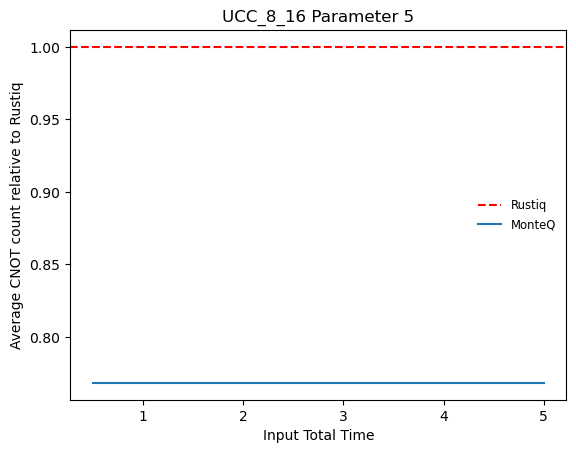

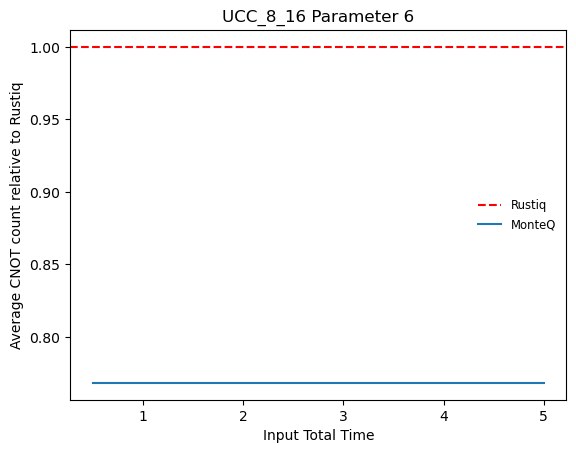

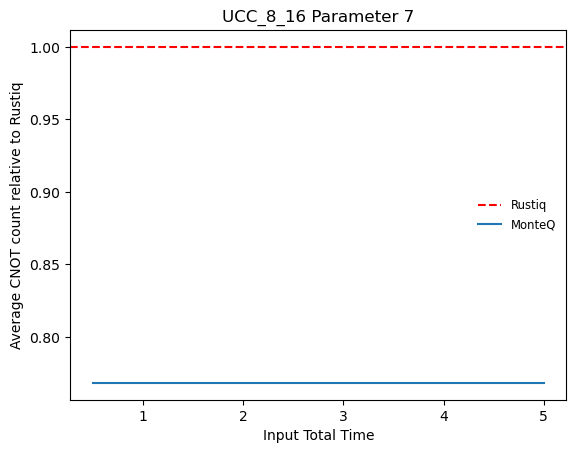

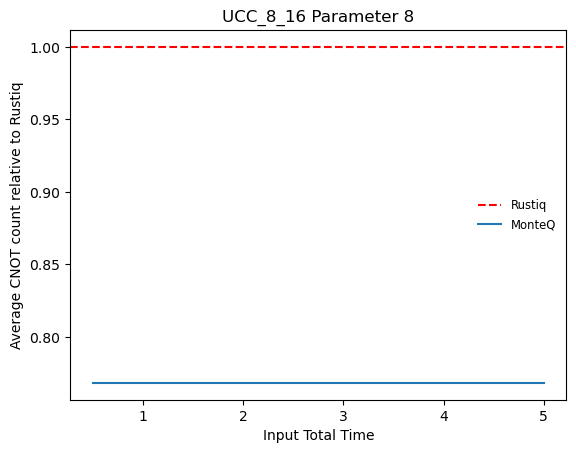

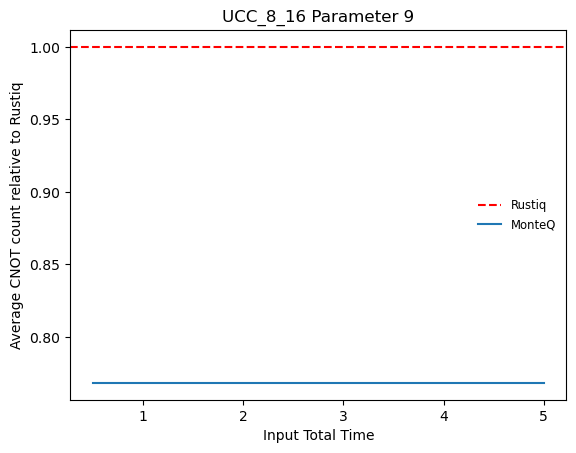

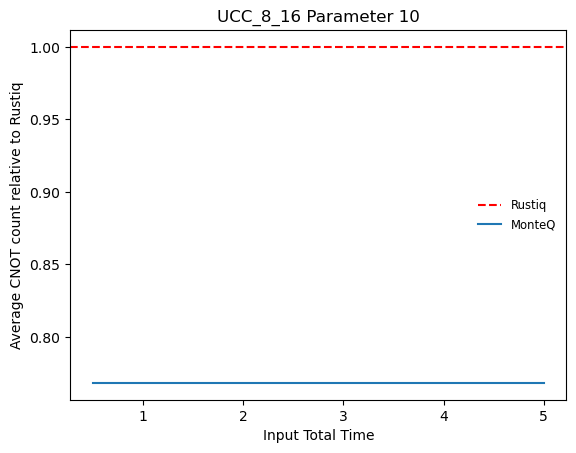

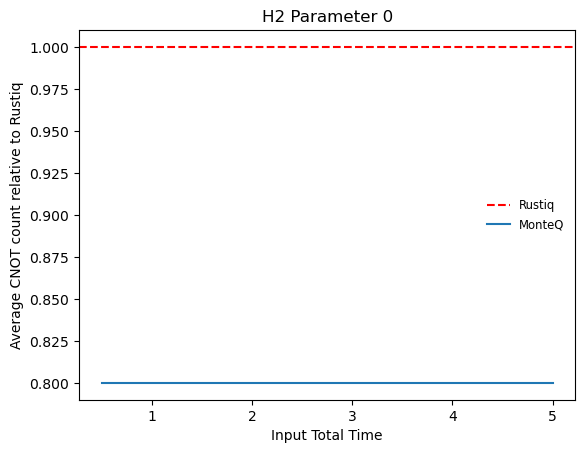

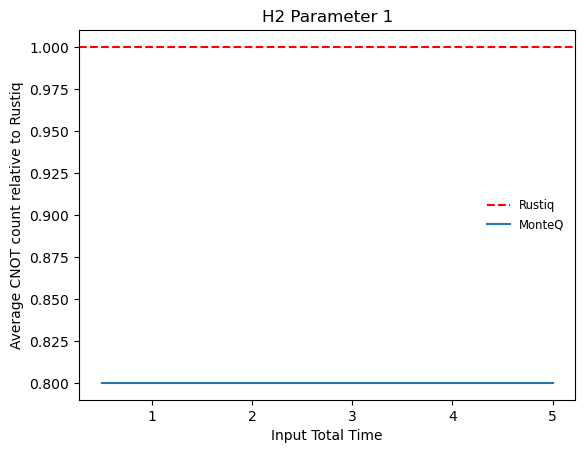

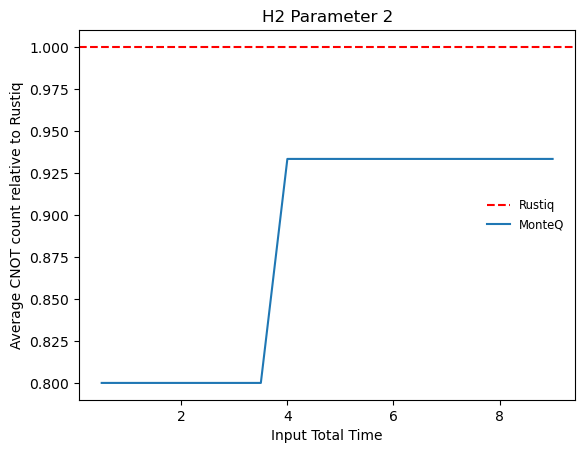

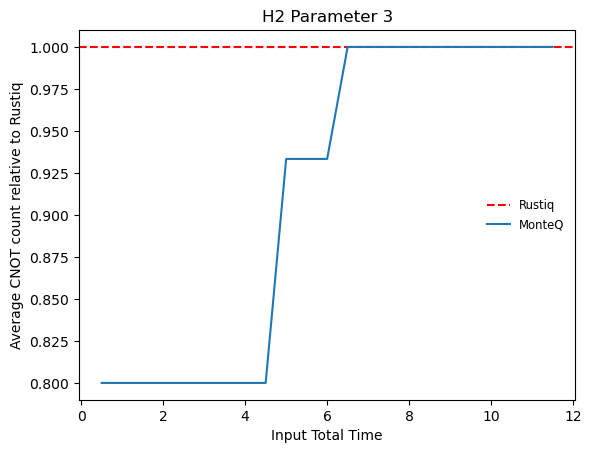

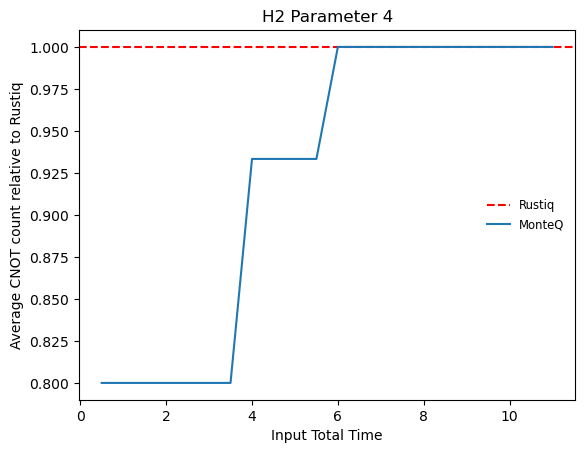

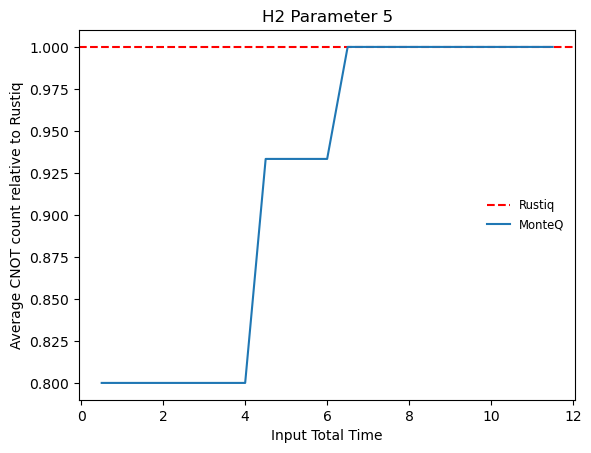

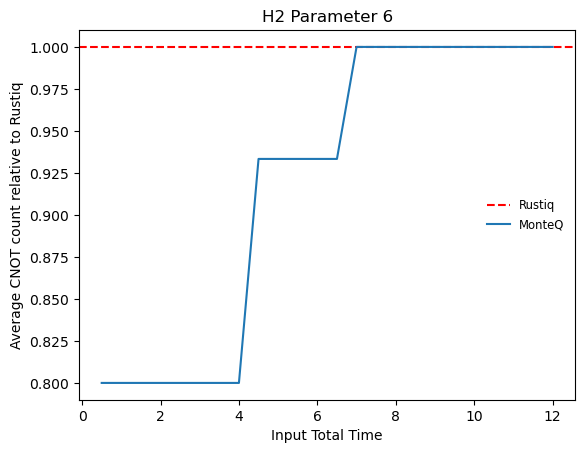

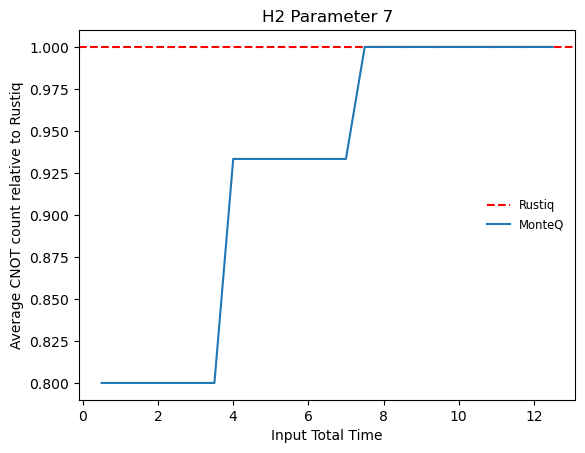

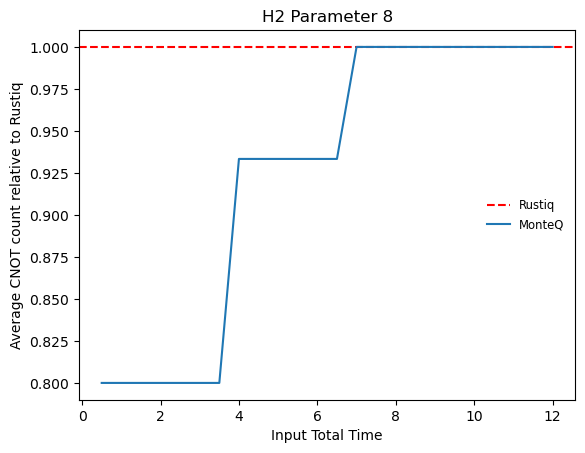

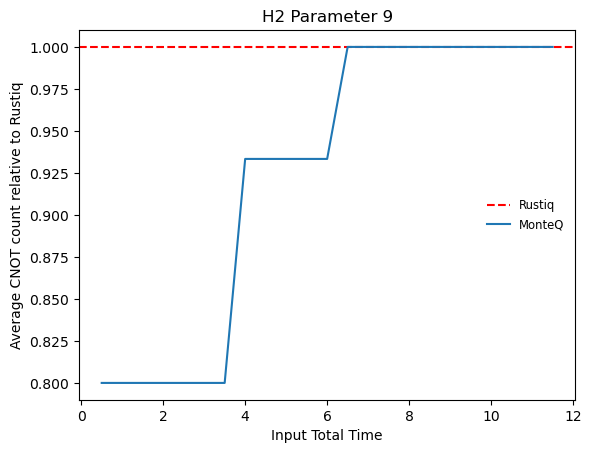

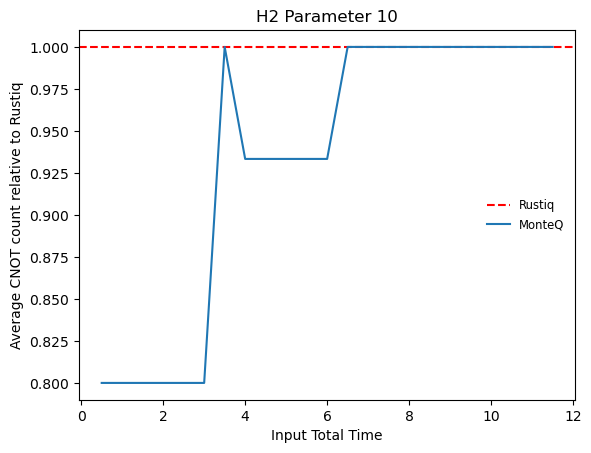

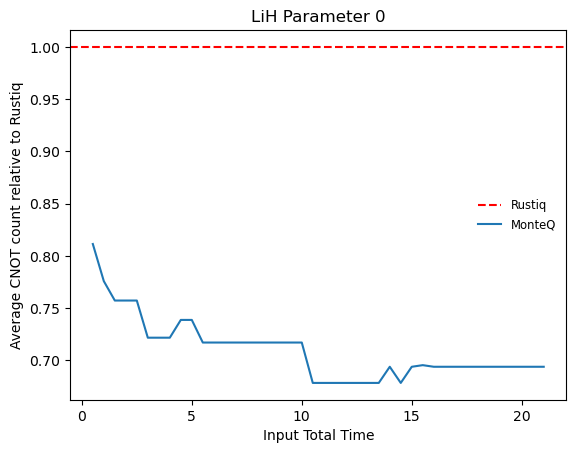

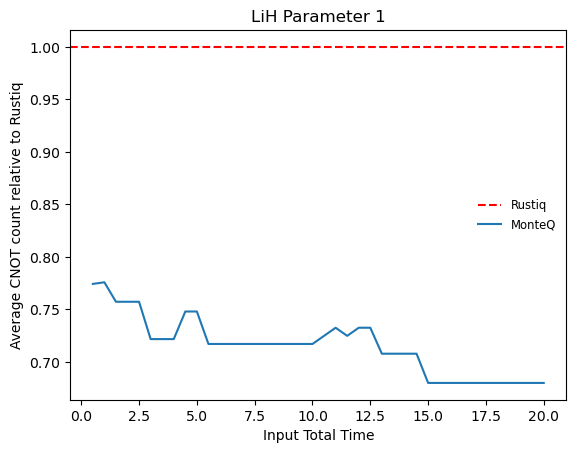

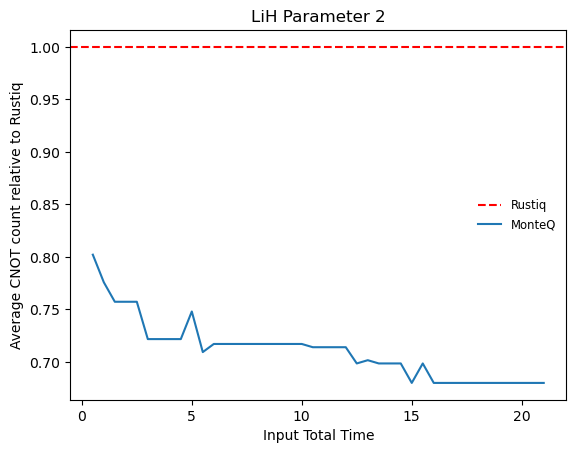

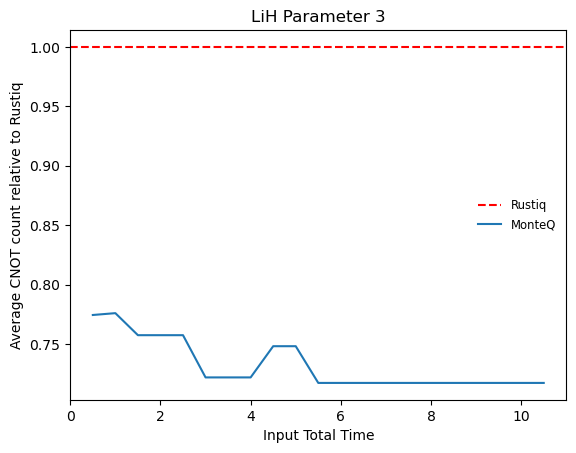

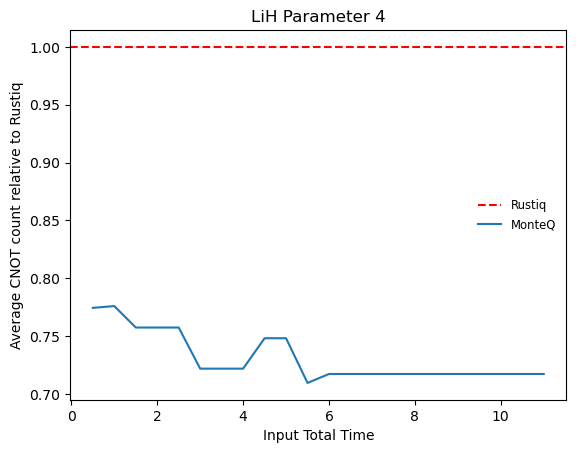

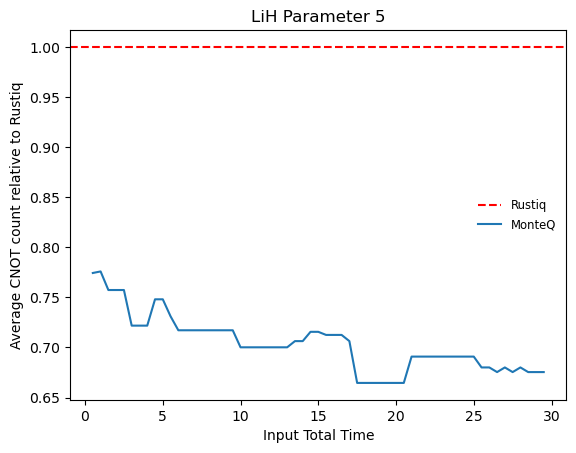

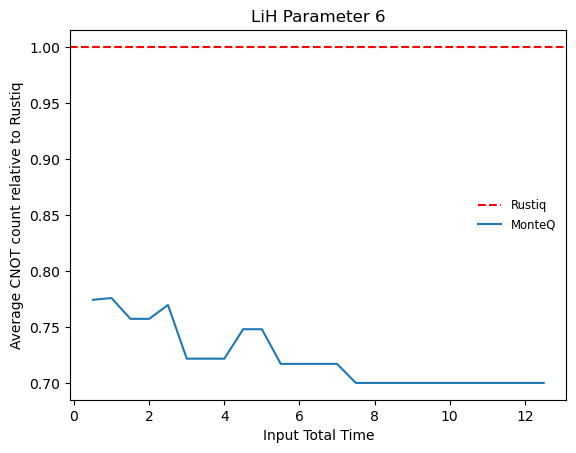

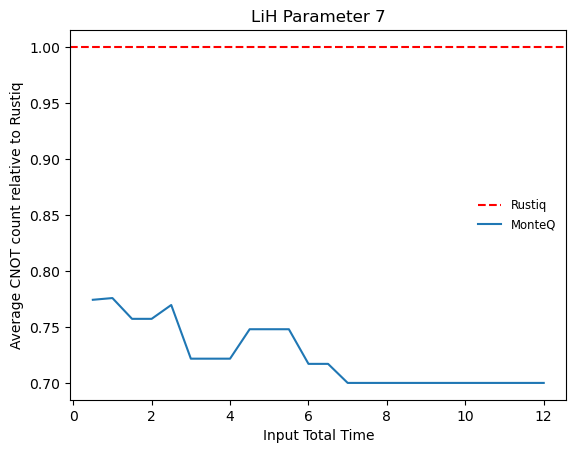

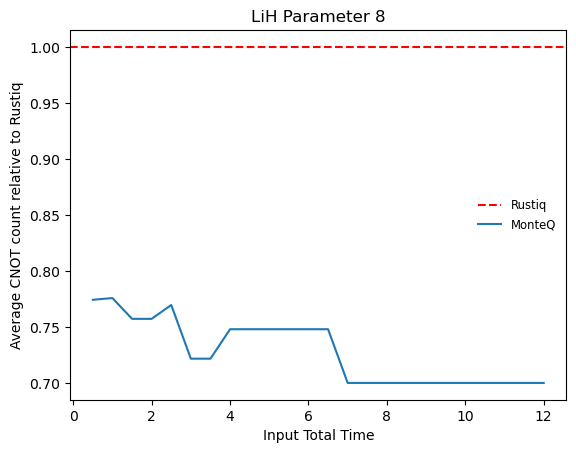

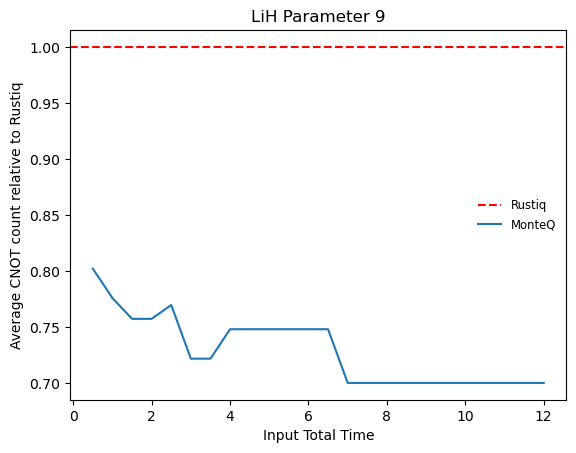

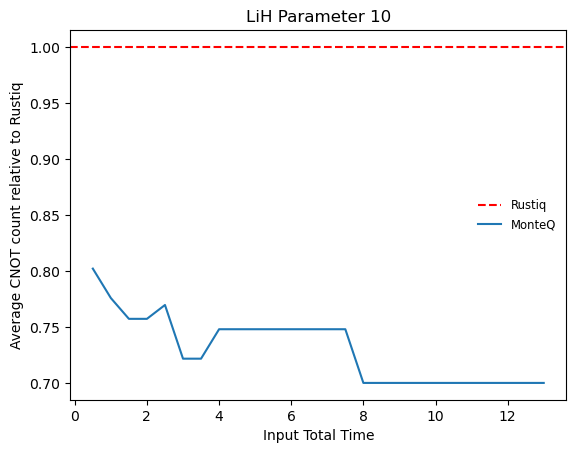

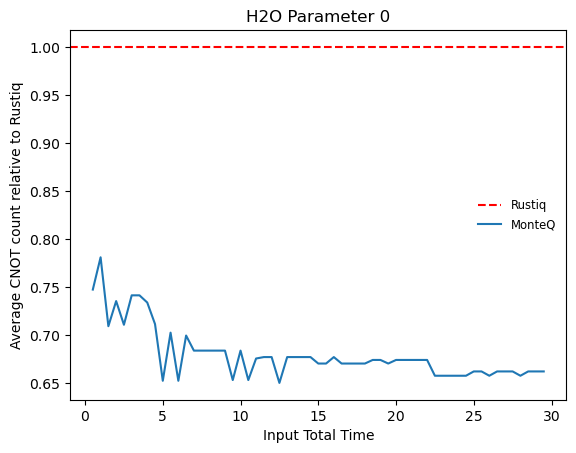

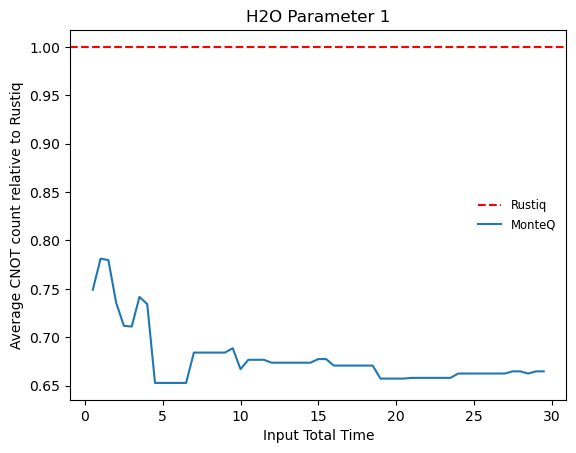

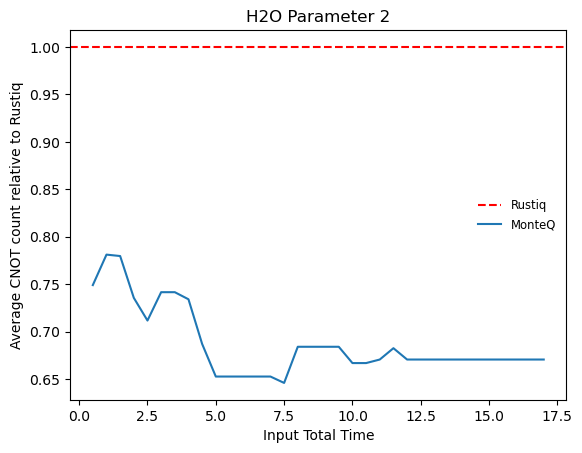

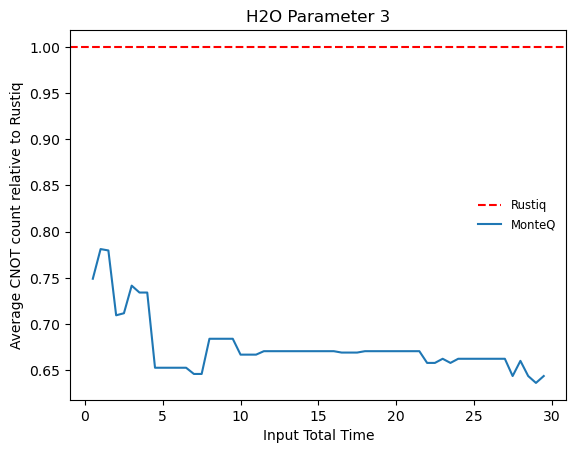

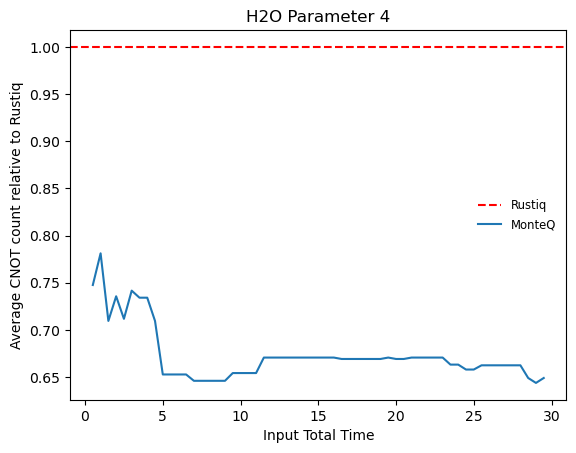

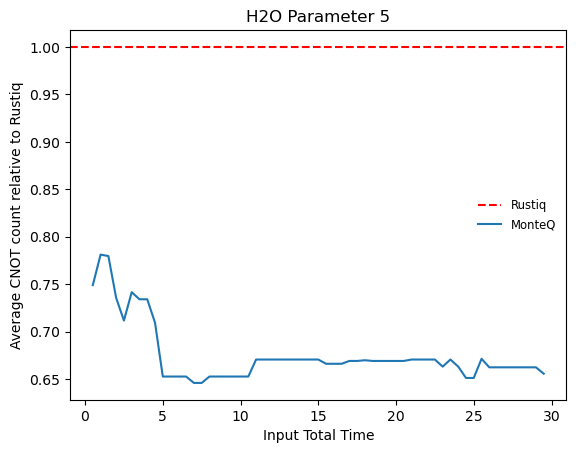

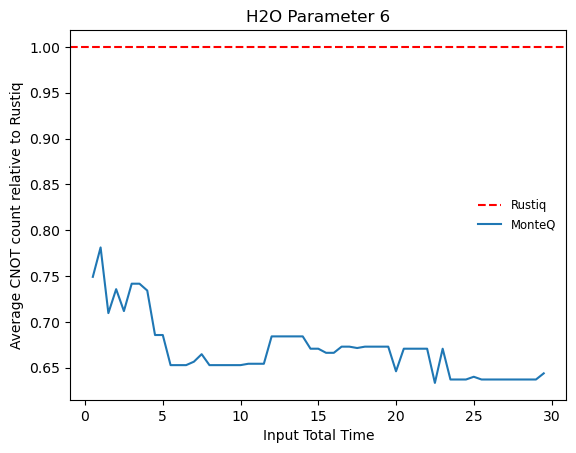

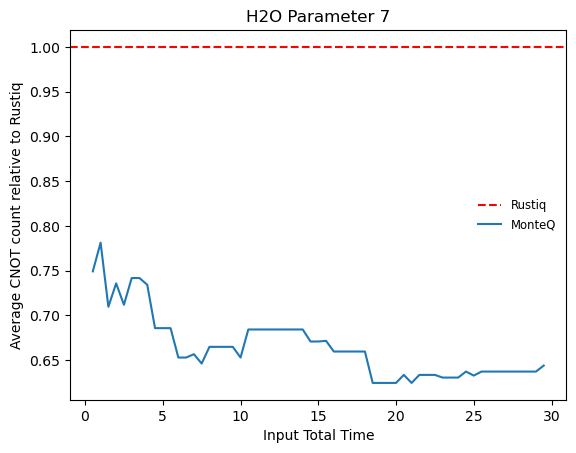

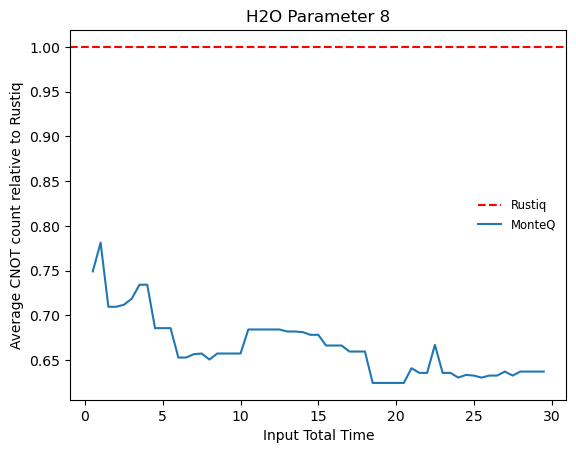

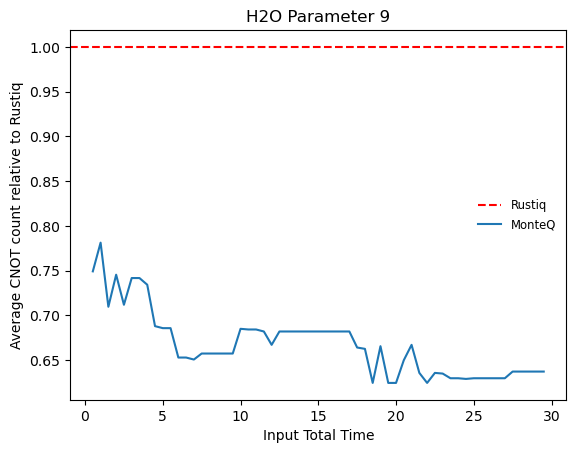

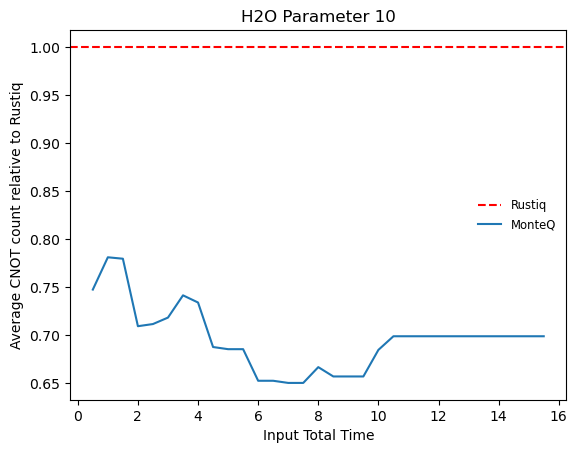

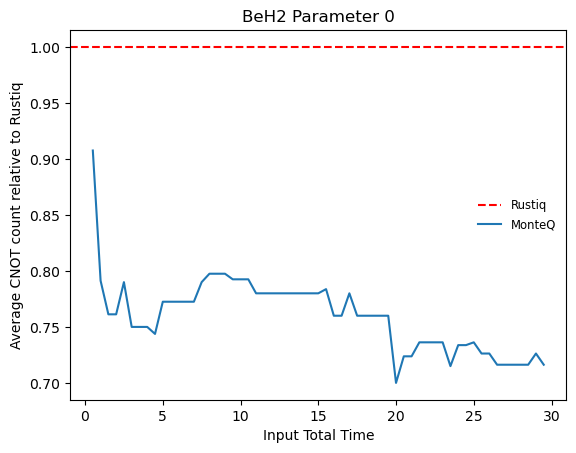

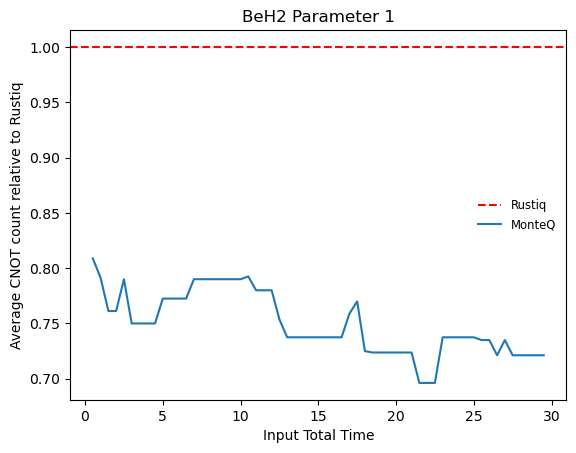

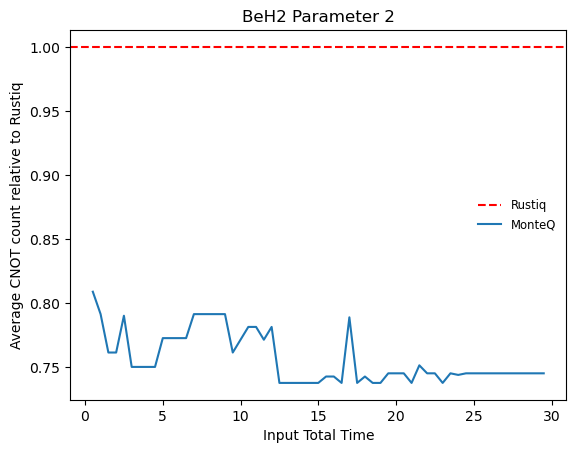

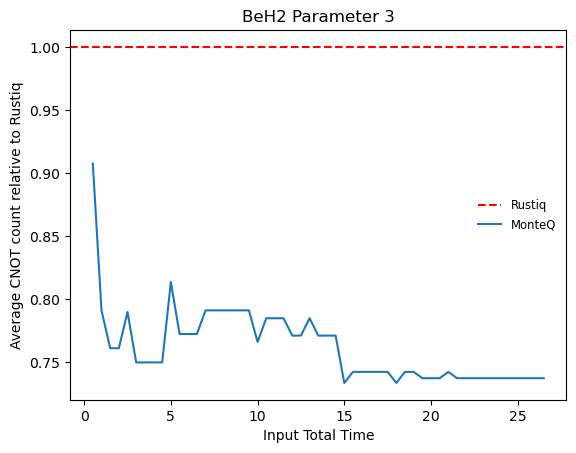

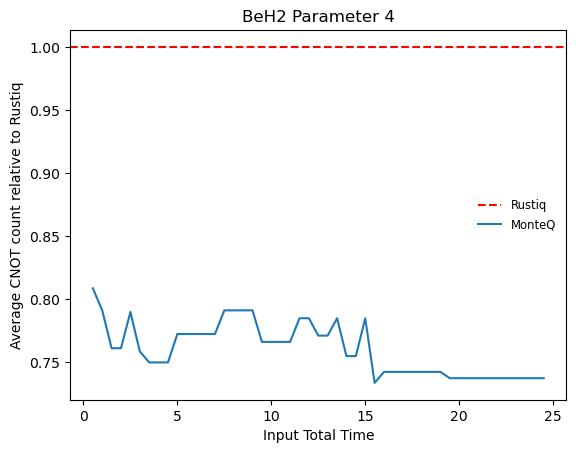

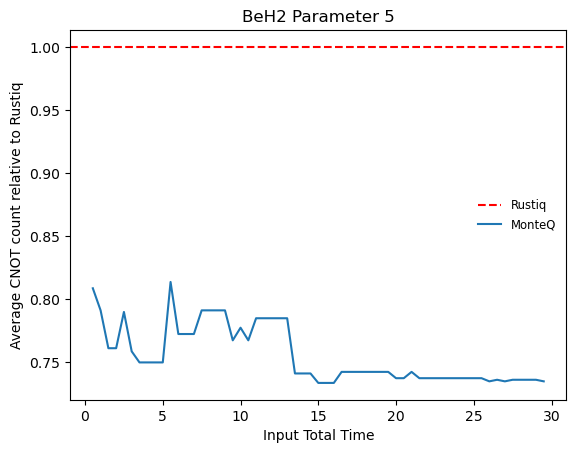

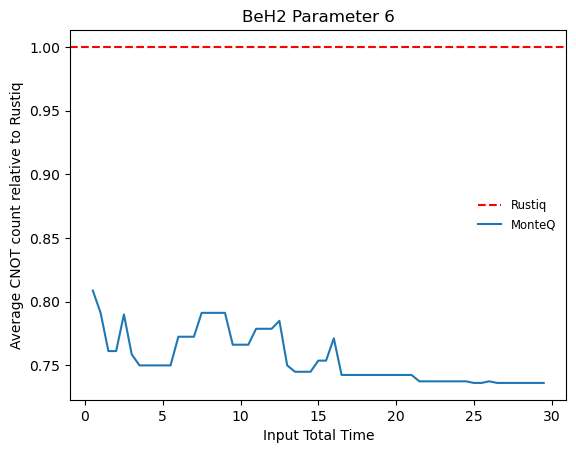

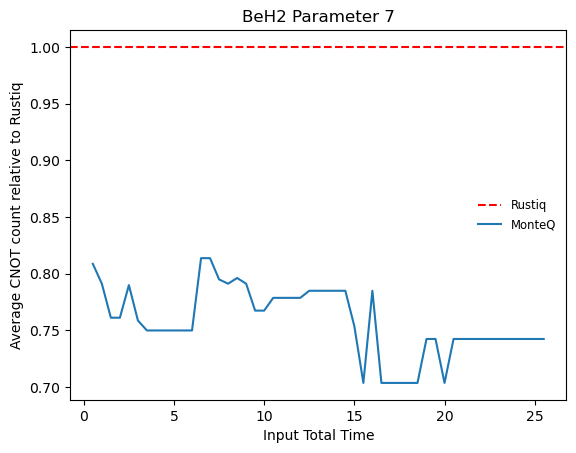

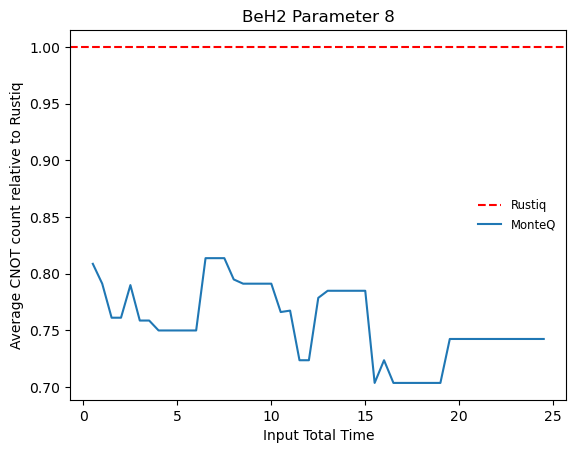

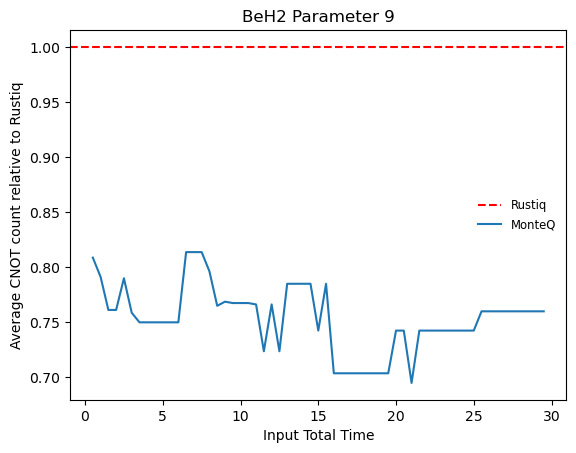

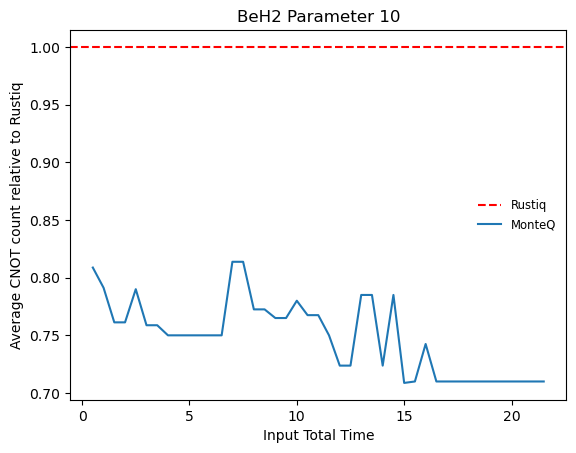

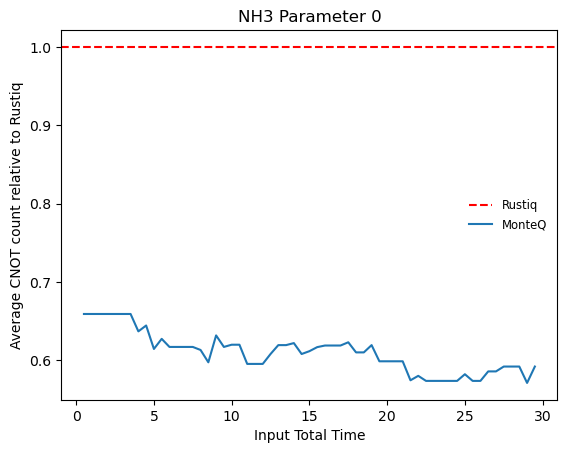

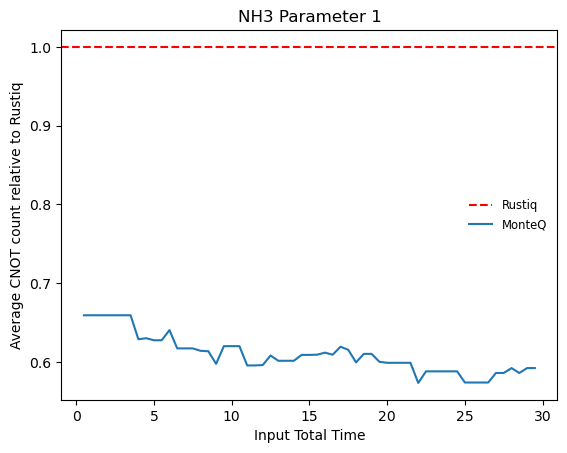

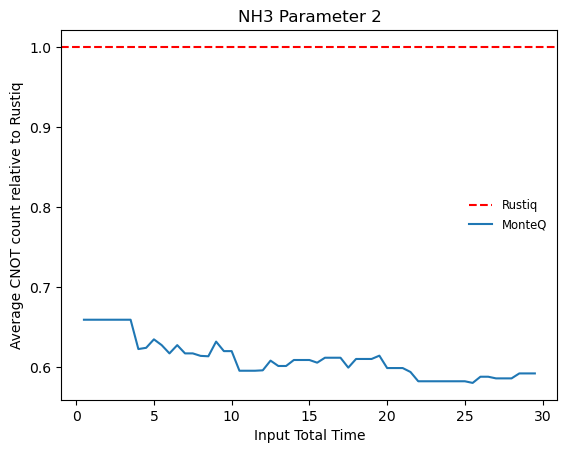

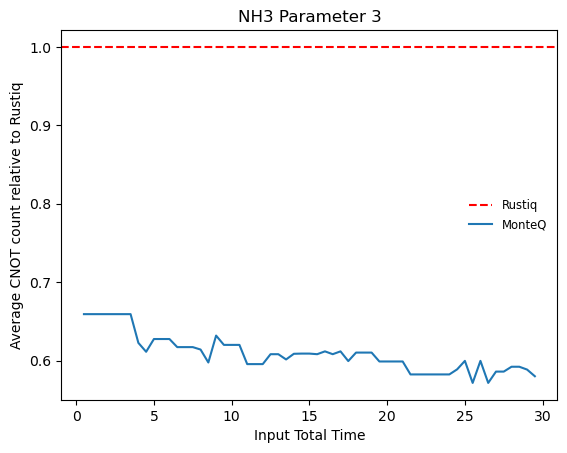

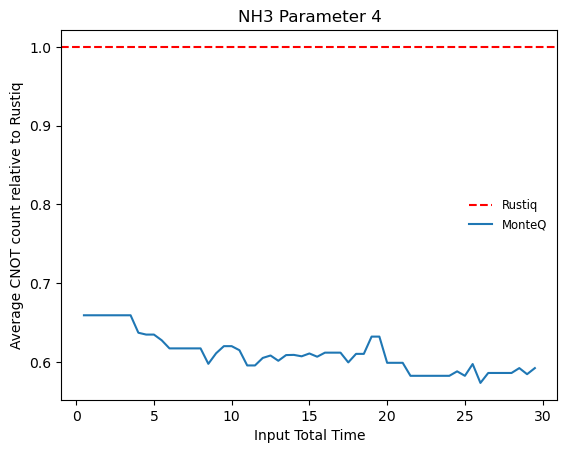

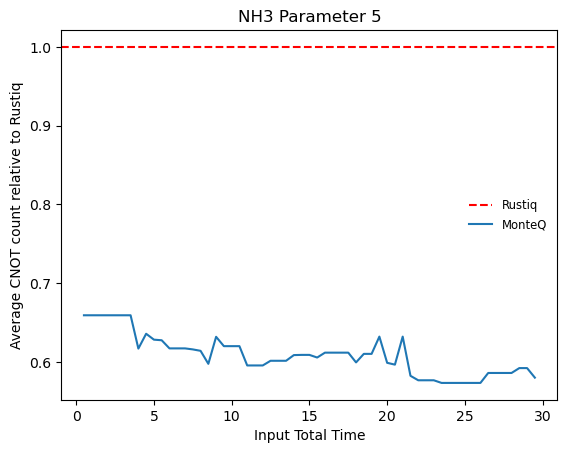

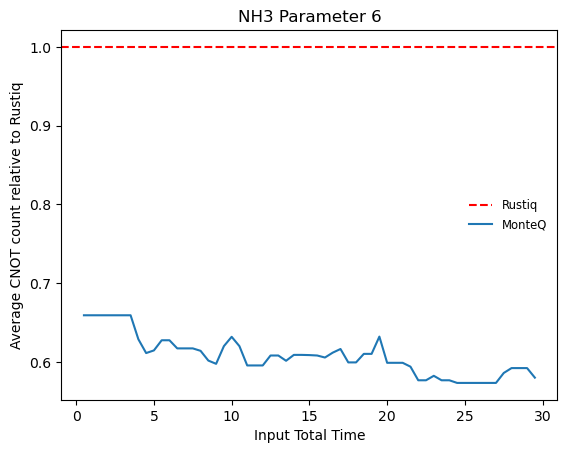

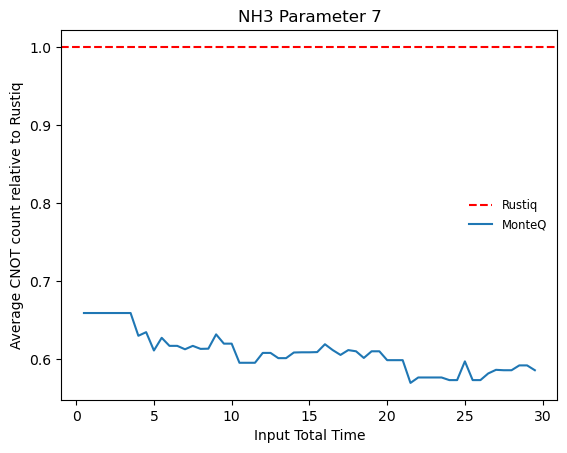

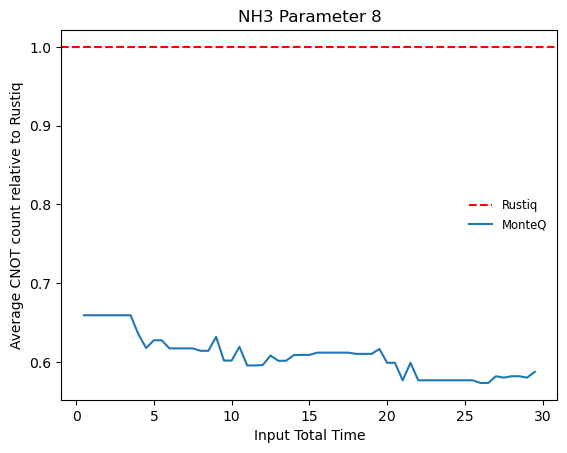

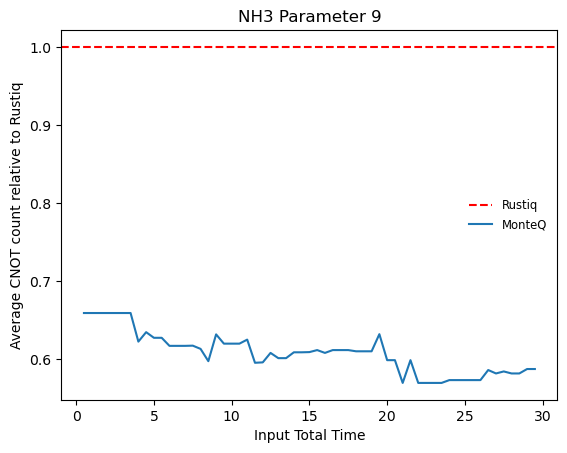

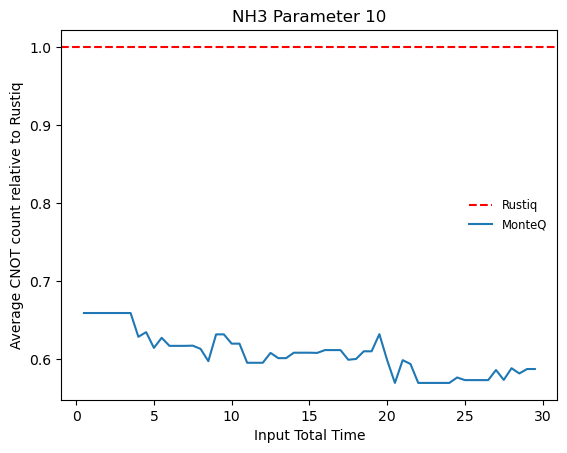

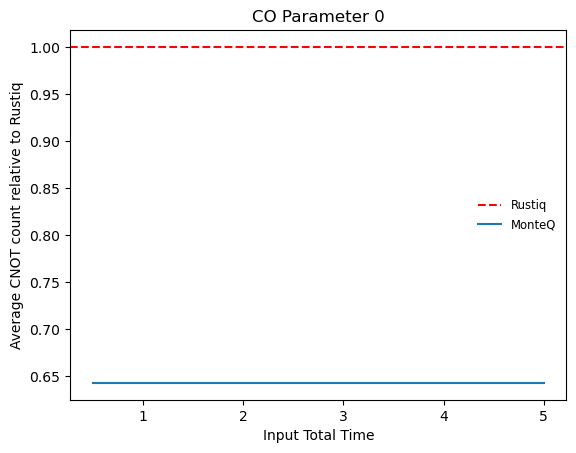

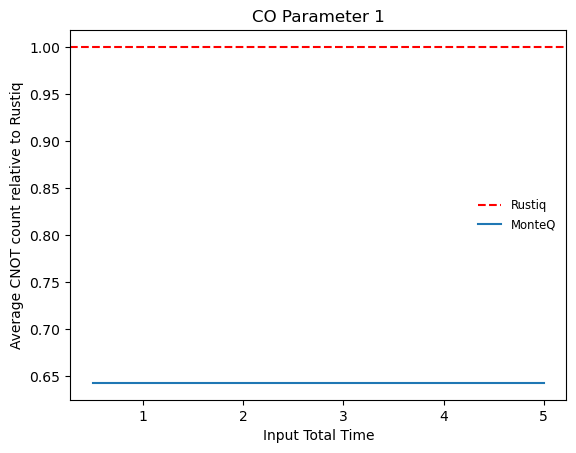

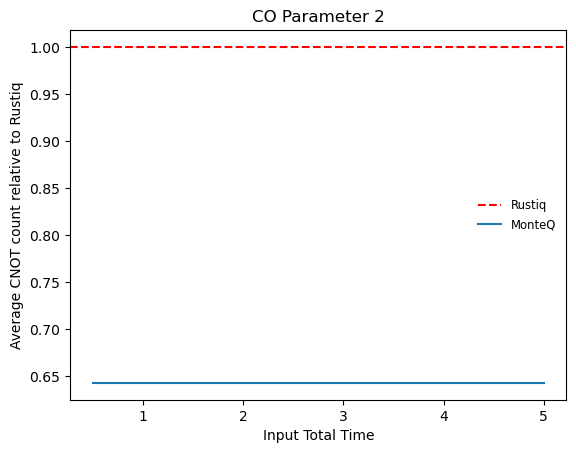

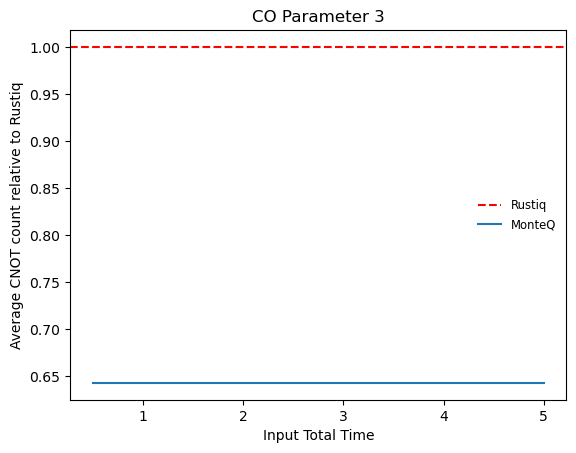

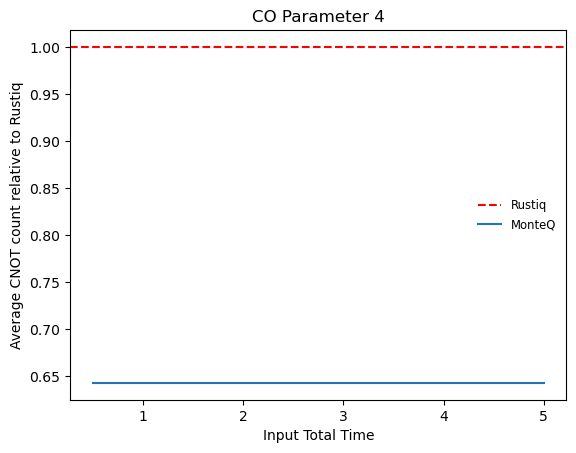

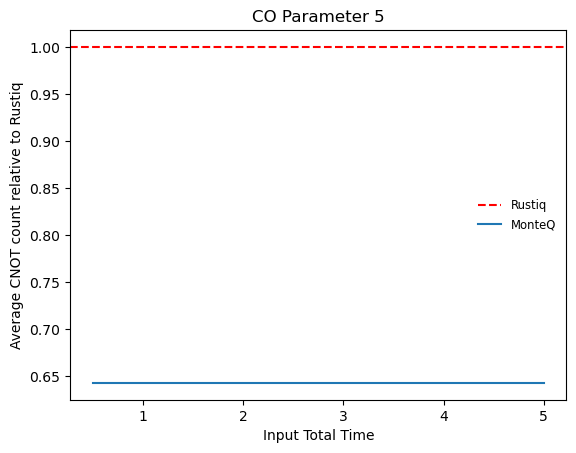

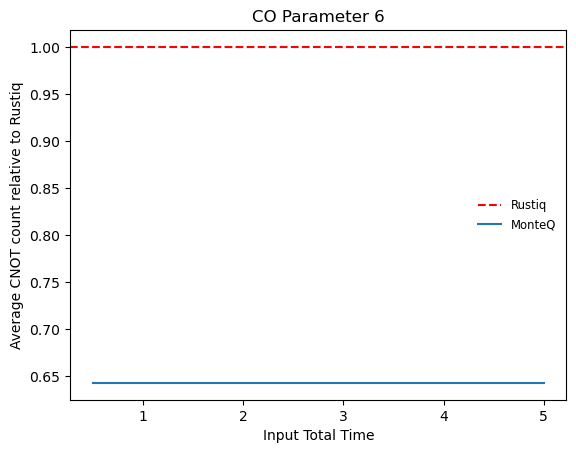

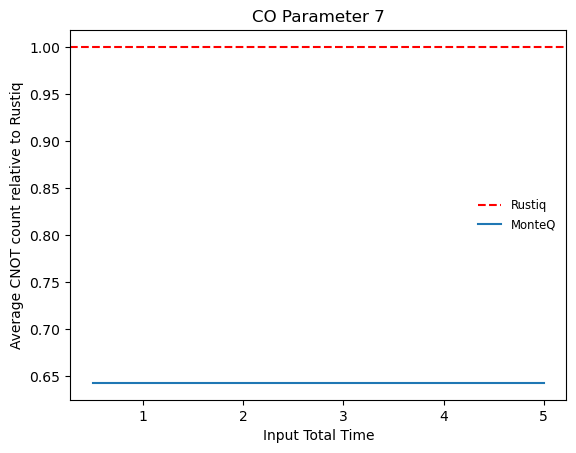

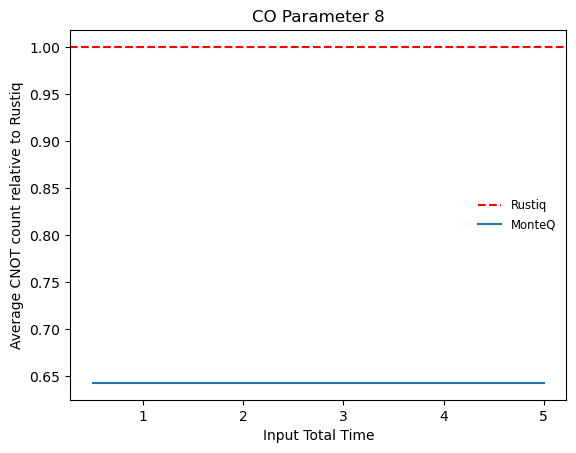

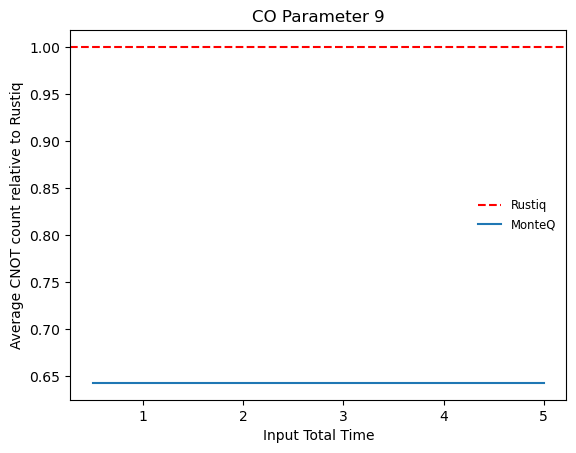

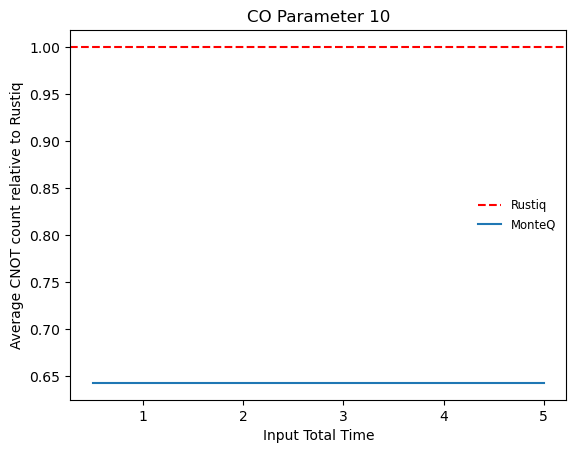

In [68]:
#results = {"cutoff": 50}
ls = ["UCC_2_4.pkl", "UCC_4_8.pkl", "UCC_6_12.pkl", "UCC_8_16.pkl", "H2.pkl", "LiH.pkl", "H2O.pkl", "BeH2.pkl", "NH3.pkl", "CO.pkl" ]
values = [ucc_2_4_rustiq, ucc_4_8_rustiq, ucc_6_12_rustiq, ucc_8_16_rustiq, H2_rustiq, LiH_rustiq, H2O_rustiq, BeH2_rustiq, NH3_rustiq, CO_rustiq]
for filename, value in zip(ls, values):
    make_graph(filename, value)

In [46]:
with open("results.json", "w") as f:
    json.dump(results, f)